In [1]:
#!python3 -m jupyter kernelspec install-self
print('Hello World')

##Test case to make sure Jupyter is running

Hello World


In [ ]:
!pip install openpyxl
!mamba install pandas
!mamba install scikit-learn
!mamba install seaborn
!mamba install warnings
!mamba install matplotlib
##^ install block

mambajs 0.19.13

Process pip requirements ...

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 5.56 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscript

Cannot solve the request because of: No candidates were found for warnings *.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from sklearn.cluster import KMeans
##^ import block
##
wr.filterwarnings('ignore')

pd.options.display.float_format = '{:20,.2f}'.format
##^Allows the reception percentages to be percentages
df = pd.read_excel('Data Mining Movie Set.xlsx')
print(df.head())
##^reads dataset built from list of highest grossing and best recieved movies
#df.shape()
df.info()
df.describe().T
df.columns.tolist()
##^Base analysis
#df.nunique()
#df.isnull().sum()
df = df.dropna()
df = df.drop_duplicates(['Film Name'])
##^Removes films with missing data or films that appear on both sources
print(df.head())
##The final dataset contains 411 entities. The average film makes a profit of 519 million dollars, has a critical rating of 83%, and an audience score of 87%. The standard deviantion between reception is quite small, 
##showing a link between popularity and profitability. Note that the general public has less variety than professional critics. However, the standard deviation of the box office shows otherwise. There is about 507 million dollars
##worth of variency in the dataset, ranging from the low millions to just over a billion dollar profit. Perhaps the reason why the variety in opinions and the variety in profit are so different is in how reviews are calculated. If 9 out of
##10 critics approve the film, then it has a 90% critical response. This happens for films with hundreds of reviews as well as films who only get 10 critics. The quartiles paint a similar picture. While Q2 has a $482 million box office and
##a 91% audience reception, Q3 has nearly double the box office yet a 3% increse in audience scores. 

                      Film Name  Worldwide Box Office    Critical Response  \
0                     Pegasus 3        641,059,523.00                  NaN   
1             Project Hail Mary        638,442,784.00                 0.94   
2  The Super Mario Galaxy Movie        750,734,310.00                 0.43   
3             A Minecraft Movie        960,387,780.00                  NaN   
4             A Minecraft Movie        961,187,780.00                 0.47   

     Audience Response  Year of Release  
0                 0.97             2026  
1                 0.95             2026  
2                 0.89             2026  
3                  NaN             2025  
4                 0.84             2025  
<class 'pandas.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Film Name             648 non-null    object 
 1   Worldwide Box Office  645 no

In [3]:
df.describe()

,Worldwide Box Office,Critical Response,Audience Response,Year of Release
count,414.00,414.00,414.00,414.00
mean,"521,180,447.76",0.83,0.87,"1,999.09"
std,"505,615,128.09",0.17,0.12,24.01
min,399.00,0.18,0.41,"1,921.00"
25%,"33,781,836.00",0.77,0.84,"1,990.25"
50%,"486,601,341.00",0.90,0.91,"2,008.00"
75%,"824,121,201.00",0.94,0.94,"2,016.00"
max,"2,923,710,708.00",1.00,1.00,"2,026.00"


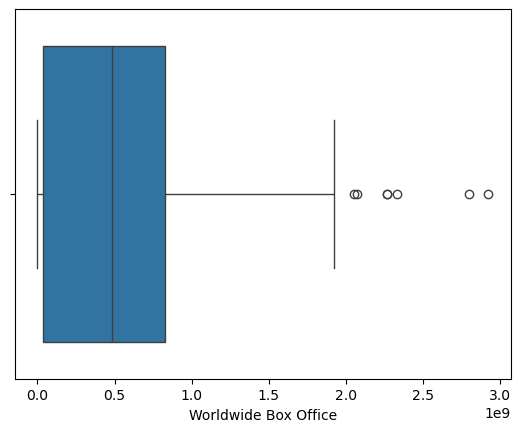

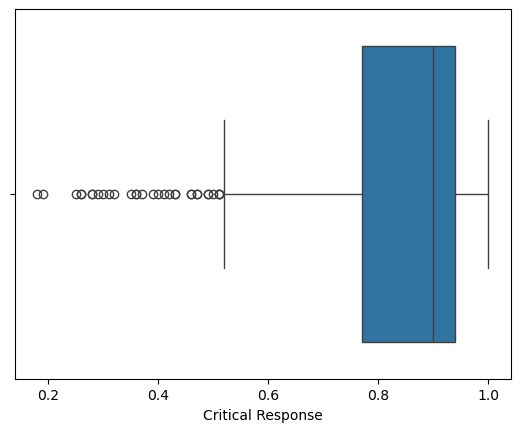

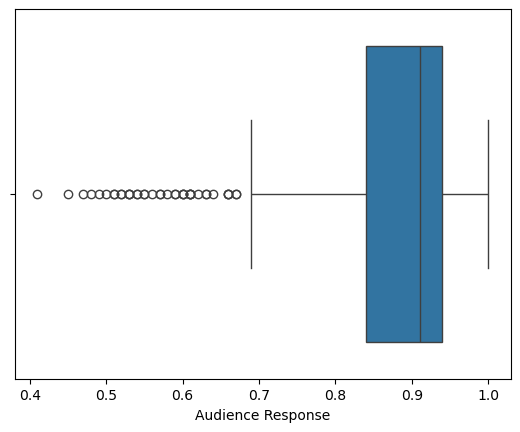

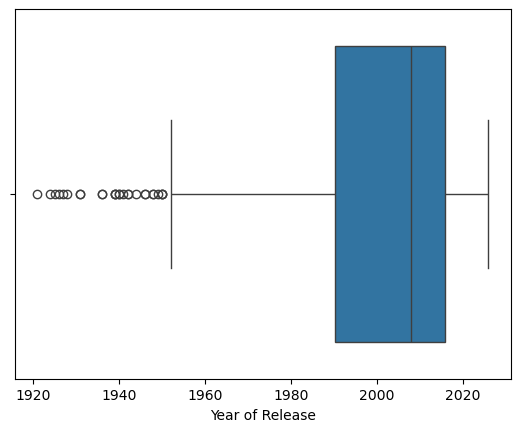

In [4]:
dm = sns.boxplot(x=df['Worldwide Box Office'])
plt.show()
dm = sns.boxplot(x=df['Critical Response'])
plt.show()
dm = sns.boxplot(x=df['Audience Response'])
plt.show()
dm = sns.boxplot(x=df['Year of Release'])
plt.show()
##Box Office has its quartiles below a billion dollar profit (as per the mean) and ends at around 1.8 billion dollars. The few outliers shown are for films with more than 2 billion in profit. 
##Looking at the raw data, most of these points are Avengers films. Both responses are clustered around positive reviews (80% to 90%) with a negative skew. 
##Due to critics having higher standards and varied tastes, their plot strecthes down to 50%. Audiences are driven more by personal feelings which means a smaller range. 
##However, audiences have more single responses and outliers compared to critics
##The box for release year starts around 1990 while the plot extends back to the 50s, matchin up with the popularity of movies during those eras.

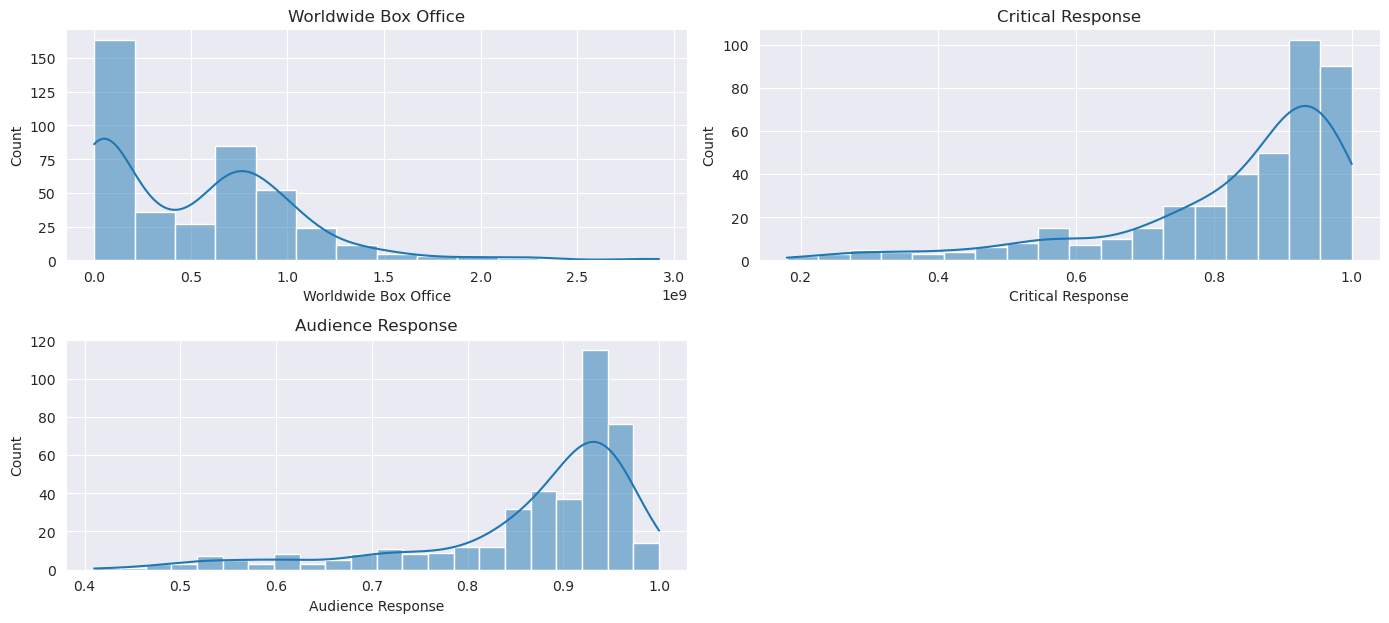

In [5]:
#fig = plt.figure(figsize = (10, 10))
sns.set_style("darkgrid")

float_columns = df.select_dtypes(include=["float64"]).columns
plt.figure(figsize=(14, len(float_columns) * 3))
for idx, feature in enumerate(float_columns, 1):
    plt.subplot(len(float_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature}")
plt.tight_layout()
plt.show()
##Responses have a heavy preference towards positivity. However, audiences and critics do have some unique qualities. The critics believe in the idea of a perfect movie more than the audiences as seen in the higher count of  ~90% and 
##the drop at 100% seen in the latter graph. There is a bump around 54% in the critical response graph for devisive films while the audience reaction graph has a flatter bar for bad films. Speaking of the shape, the critical response
##graph rises faster than the audience graph because the amount of professional views are more spread out across the scores. 

##As for the Box office graph, it's quantified in the billions so the two peaks are built from the movies which didn't even crack into the millions and the enstallments of famous franchises. 

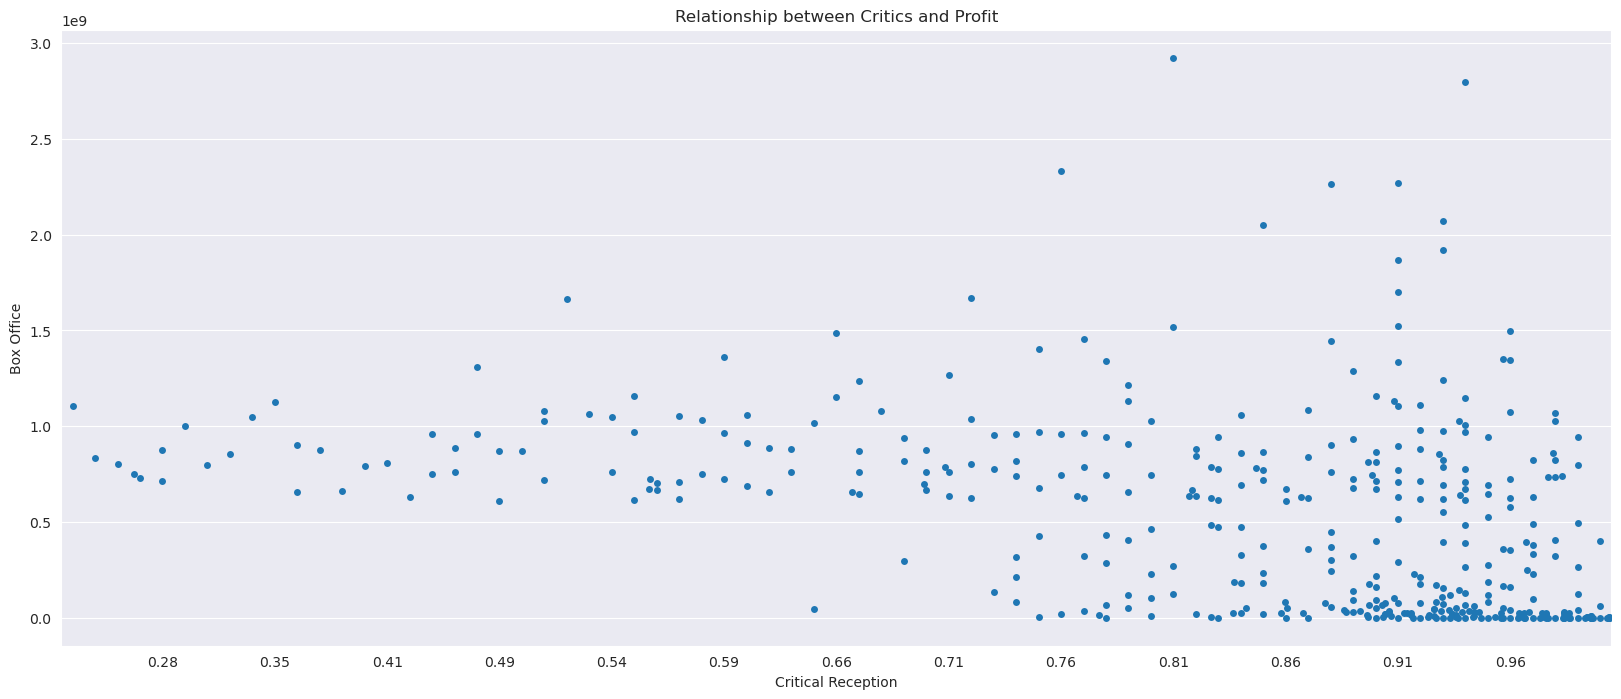

In [6]:
plt.figure(figsize=(20, 8))

dm = sns.swarmplot(x="Critical Response", y="Worldwide Box Office", data=df, dodge=True)
ticks = dm.get_xticks()
dm.set_xticks(ticks[4::5]) #This one part was kicking my ass
plt.title('Relationship between Critics and Profit')
plt.xlabel('Critical Reception')
plt.ylabel('Box Office')
plt.show()
##An 800 million dollar profit seems to be a universal standard for films regardless of how it was reviewed. The massive clump of highly praised but low profit films could be a sign of small demographics, 
##or it could be caused by the way ratings or profits are calculated

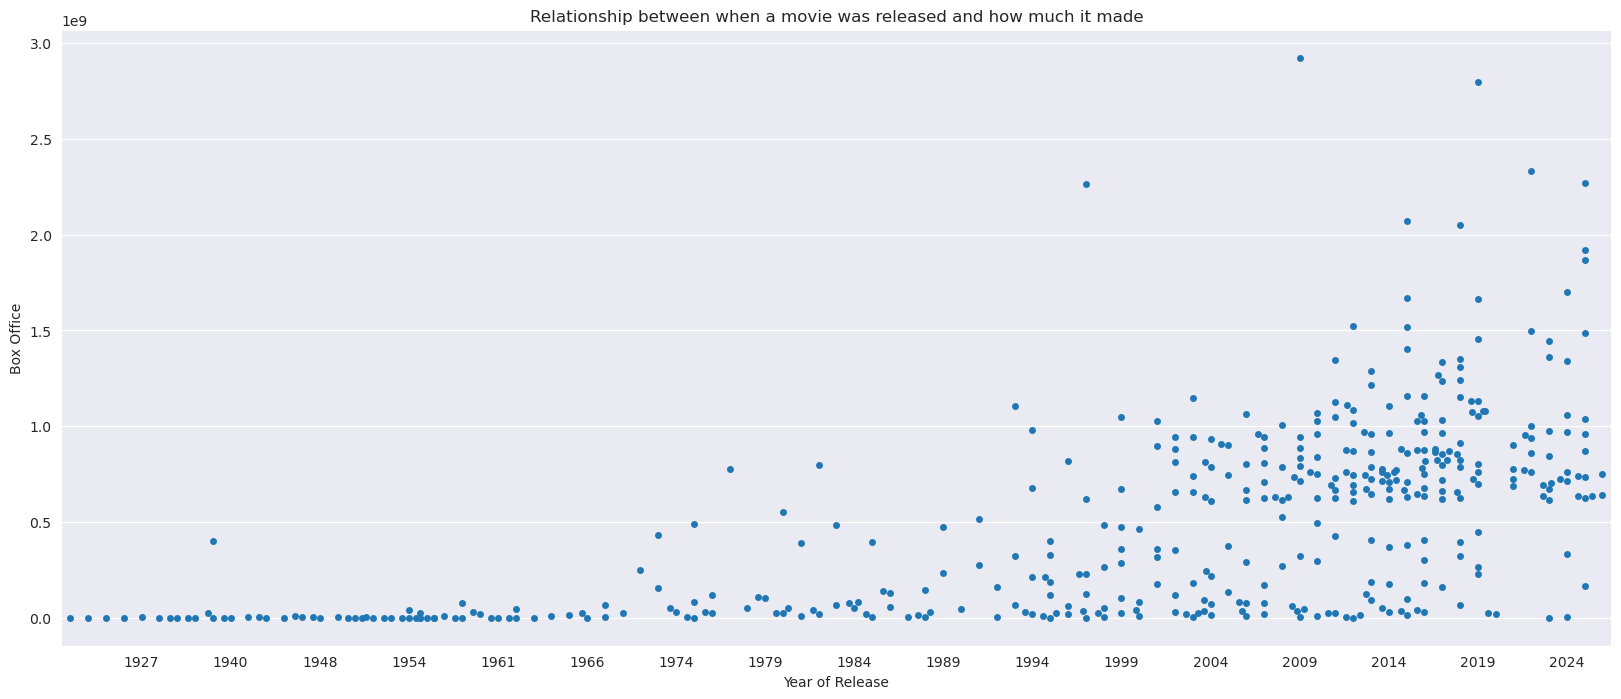

In [7]:
plt.figure(figsize=(20, 8))

dm = sns.swarmplot(x="Year of Release", y="Worldwide Box Office", data=df, dodge=True)
ticks = dm.get_xticks()
dm.set_xticks(ticks[4::5])
plt.title('Relationship between when a movie was released and how much it made')
plt.xlabel('Year of Release')
plt.ylabel('Box Office')
plt.show()
##Before the 1970s, films were expected to make less than 100 milion dollars in profit. However, as certain films started making more money, some 'waves' begin to form. This created the new baseline in the early 2000s, where 
##a billion dollar profit (give or take) was expected for major movies. The original baseline still exists but has expanded to films that made up to 300 million. Meanwhile, extremely marketed films have reached 1.5 billion and rising.

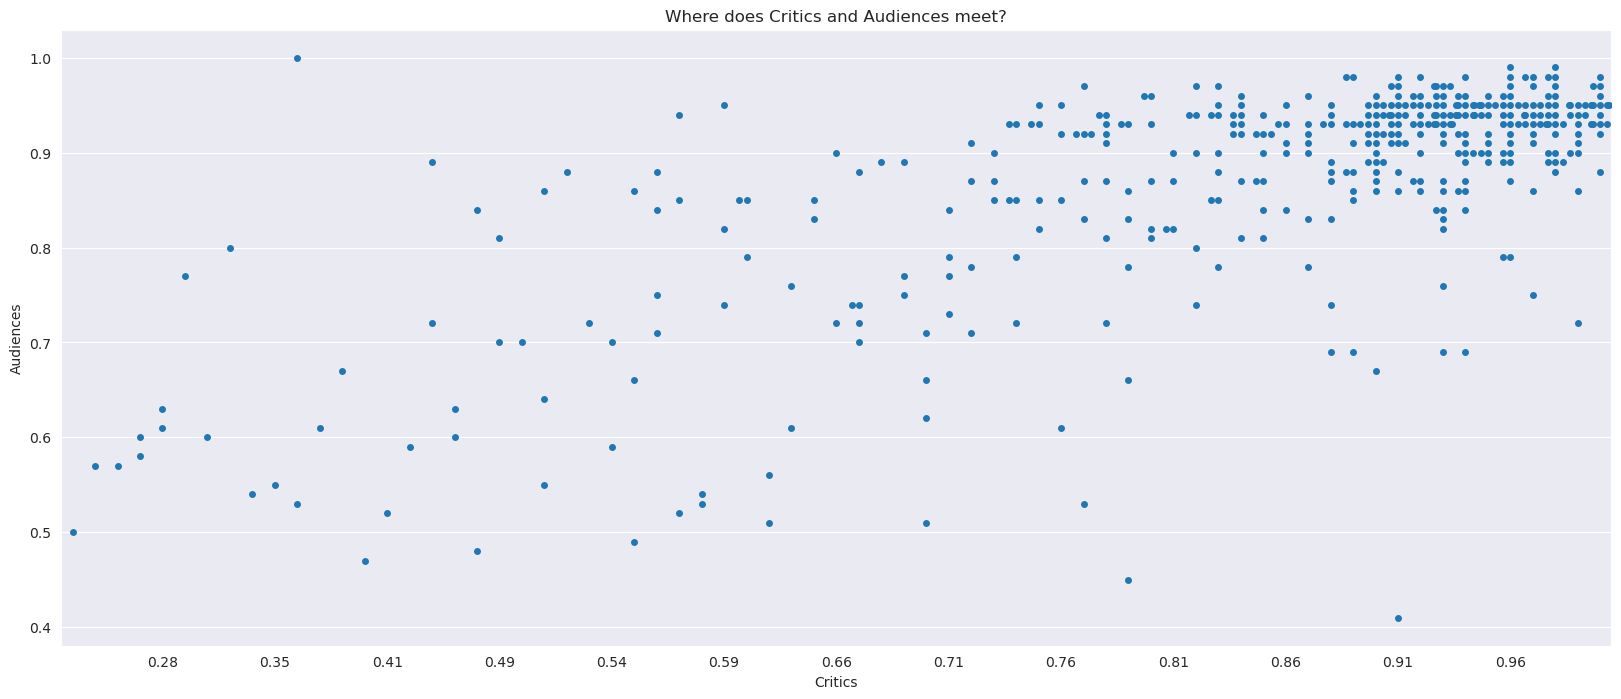

In [8]:
plt.figure(figsize=(20, 8))

dm = sns.swarmplot(x="Critical Response", y="Audience Response", data=df, dodge=True)
ticks = dm.get_xticks()
dm.set_xticks(ticks[4::5])
plt.title('Where does Critics and Audiences meet?')
plt.xlabel('Critics')
plt.ylabel('Audiences')
plt.show()
##Strange lack of "Pretensious" films that are loved by critics but hated by audiences. Main clump are "the perfect movie". Secondary clump are films that audiences enjoyed as is but critics had issues with. This clump covers a much wider
##scope from 86% critical response to 66%

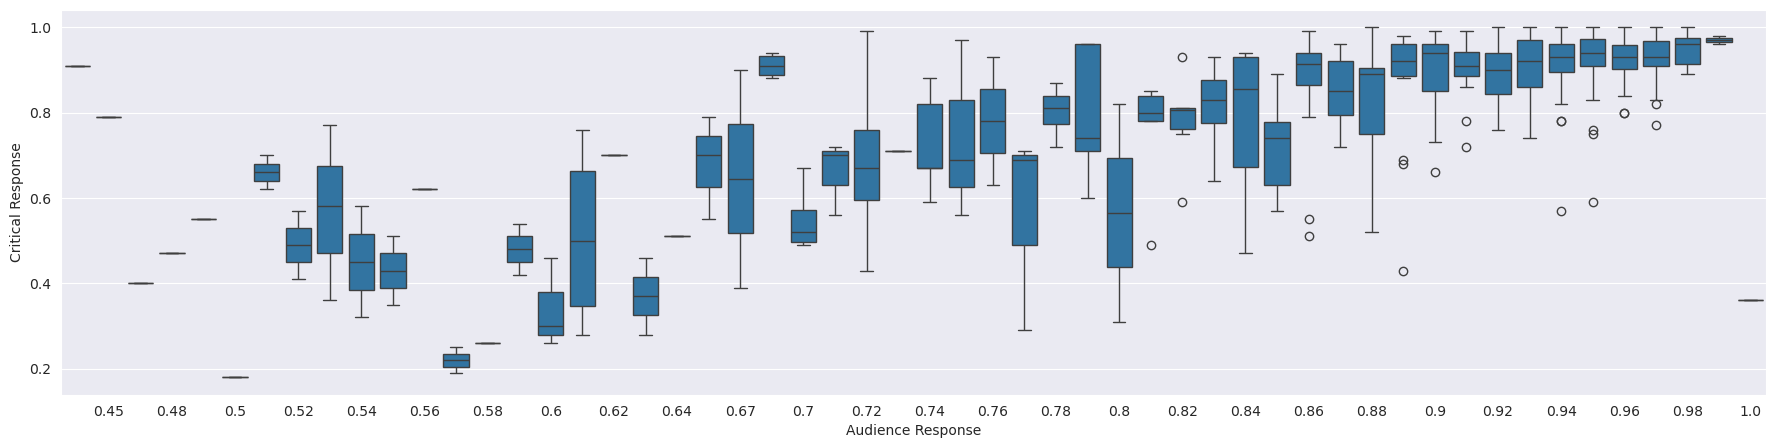

In [9]:
plt.figure(figsize=(22,5))
dm = sns.boxplot(data=df,x="Audience Response",y="Critical Response")
ticks = dm.get_xticks()
dm.set_xticks(ticks[1::2])
plt.show()
##Responses towards films become more varied the worse the audience score becomes. Based on the clusters, this is caused by films with a wider target audience (Cluster 3) attracting people who didn't like it while films with
##specific audiences (Cluster 2) only attract those who love it unconditionally. That being said, very popular films might get so much reviews from general watchers and professionals that the negativity doesn't have much of an impact, 
##as shown in Cluster 1.

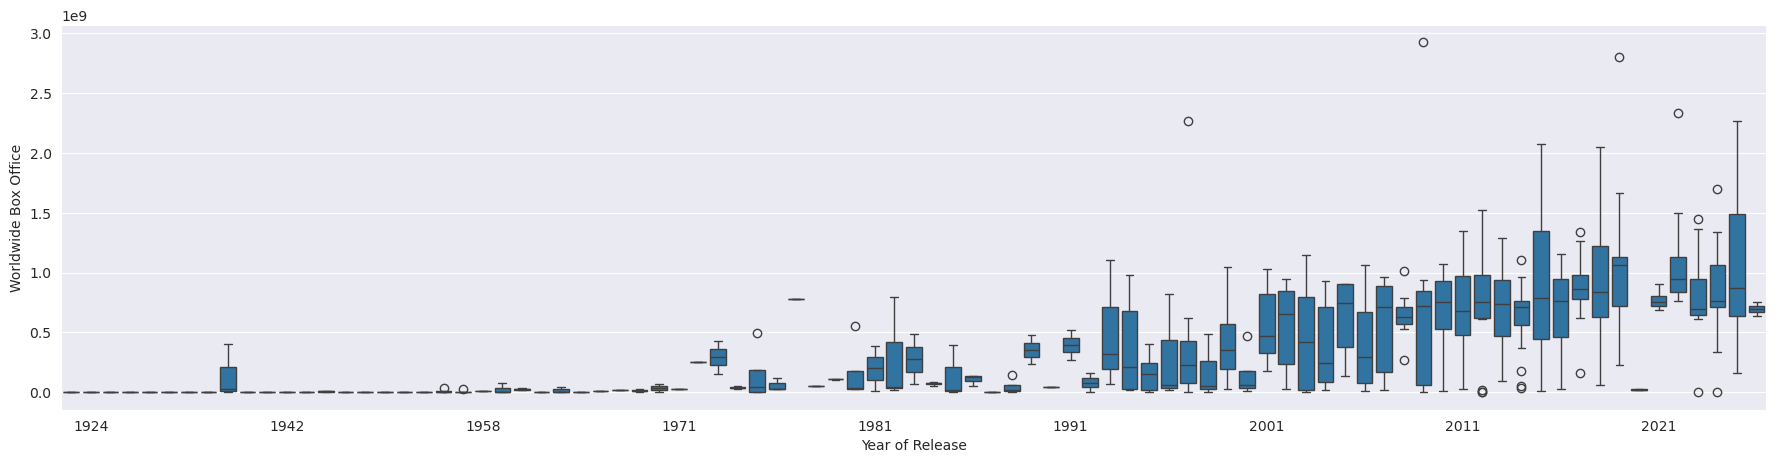

In [10]:
plt.figure(figsize=(22,5))
dm = sns.boxplot(data=df,x="Year of Release",y="Worldwide Box Office")
ticks = dm.get_xticks()
dm.set_xticks(ticks[1::10])
plt.show()
##Much more activity starting in the late 70s before rising in the 90s. The former is the start of the blockbuster and the latter is the rise of the blockbuster

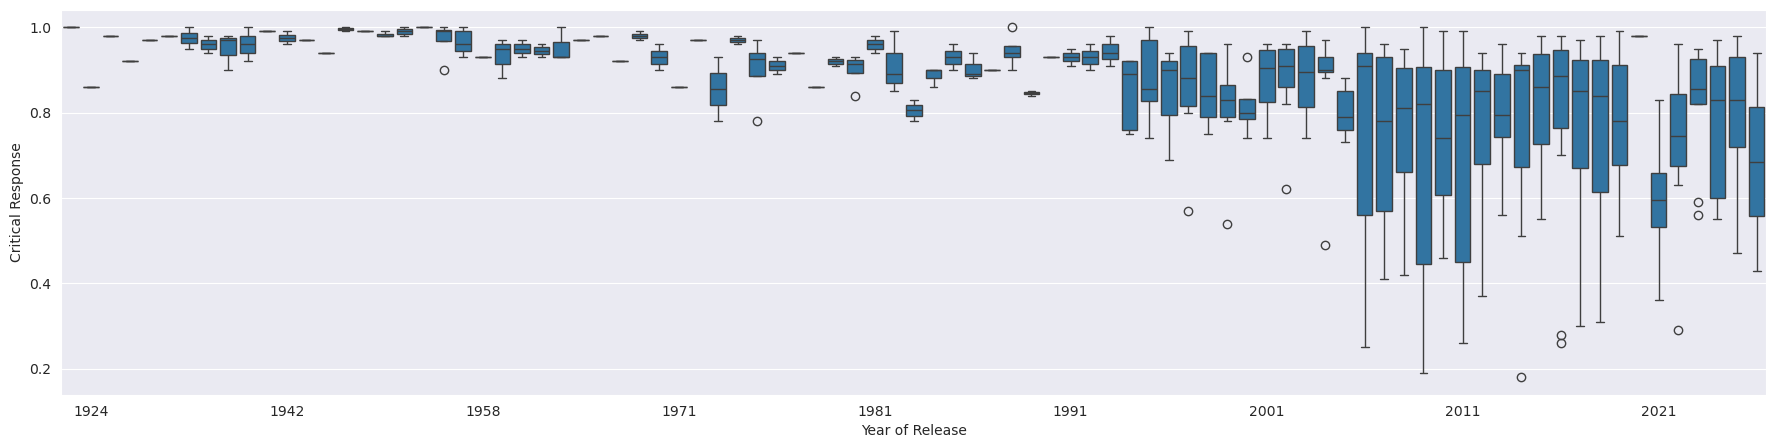

In [11]:
plt.figure(figsize=(22,5))
dm = sns.boxplot(data=df,x="Year of Release",y="Critical Response")
ticks = dm.get_xticks()
dm.set_xticks(ticks[1::10])
plt.show()
##the worse responses are more common in the last 20 or so years, mainly thanks to box office hits that apeal to such a wide audience that nothing sticks
##while older movies are drenched in a specific culture/era/idea which sticks in the minds of the viewer and ends up inspiring them to either make new
##movies or watch similar films. This is basically why franchises exist.

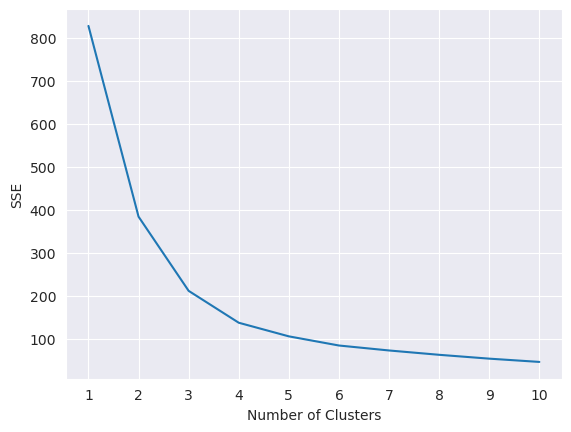

                                        Film Name  Worldwide Box Office  \
6                            Avatar: Fire and Ash                  1.91   
20                                       Ne Zha 2                  3.46   
21                        Spider-Man: No Way Home                  2.77   
26                                     Zootopia 2                  2.66   
27                           Deadpool & Wolverine                  1.62   
34                                   Inside Out 2                  2.33   
45                                         Barbie                  1.83   
60                    The Super Mario Bros. Movie                  1.66   
65                       Avatar: The Way of Water                  3.59   
79                              Top Gun: Maverick                  1.93   
101                             Avengers: Endgame                  4.51   
109                                     Frozen II                  1.85   
125                      

In [25]:
from sklearn.preprocessing import StandardScaler
df = df.dropna()
data = df.iloc[: , [1,4]].values
scaled_df = StandardScaler().fit_transform(data)
#print(scaled_df[:5])
##make sure it works

kmeans_kwargs = {
"init": "random",
"n_init": 10,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

#visualize results
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()
##
kmeans = KMeans(init="random", n_clusters=4, n_init=10, random_state=1)
##reviews 4 clusters 10 times
#fit k-means algorithm to data
kmeans.fit(scaled_df)

#view cluster assignments for each observation
kmeans.labels_

df['cluster'] = kmeans.labels_

#view updated DataFrame
print(df[df['cluster'] == 0]) #Blockbusters
print(df[df['cluster'] == 1]) #Classic
print(df[df['cluster'] == 2]) #Minivan
print(df[df['cluster'] == 3]) #Genre

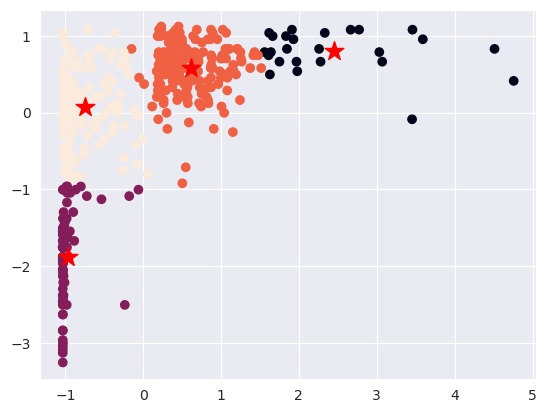

In [24]:
centroids = kmeans.cluster_centers_
#print(scaled_df)
# Plot the data points
plt.scatter(scaled_df[:, 0], scaled_df[:, 1], c=kmeans.labels_)
# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='r', s=200)
plt.show()
##scaled centroids
##4 clusters
##bottom left > line of negative values >> classics
##top left > more space between values/range in values >> genre
##middle > more dense near 1 than 0, no negative slant >> minivan
##top right > very spread out, home to highest values >> blockbusters

     Worldwide Box Office    Critical Response
1                    0.23                 0.64
2                    0.45                -2.32
4                    0.87                -2.09
6                    1.91                -0.99
7                   -0.71                 0.76
..                    ...                  ...
643                 -1.03                 0.82
644                 -1.03                 0.53
645                 -1.03                 0.87
646                 -1.03                 0.18
647                 -1.03                 0.99

[414 rows x 2 columns]


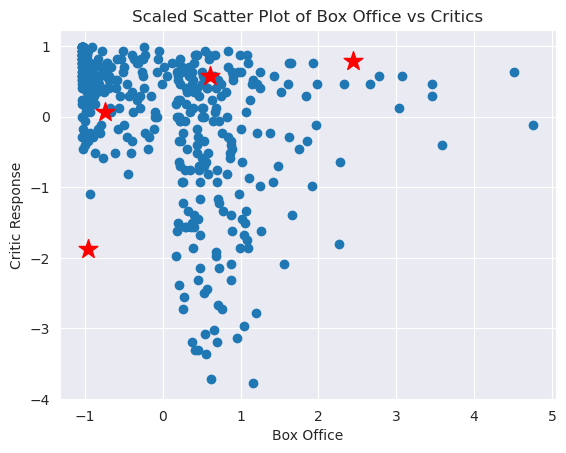

In [14]:
features = ['Worldwide Box Office', 'Critical Response']
df[features] = StandardScaler().fit_transform(df[features])
data = df[features].iloc[: , ].values
scaled_data = StandardScaler().fit_transform(data)
print(df[features])
##print(data)
##properly scaled
#sns.scatterplot(x=data[:,0], y=data[:,1], hue=df['cluster'], palette='Accent', s=100, zorder = 0)
#centroids = kmeans.cluster_centers_

# Plot the data points
#plt.scatter(scaled_df[:, 0], scaled_df[:, 1], c=kmeans.labels_)
# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='r', s=200, zorder=15)
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], zorder = 10)
plt.title('Scaled Scatter Plot of Box Office vs Critics')
plt.xlabel('Box Office')
plt.ylabel('Critic Response')
plt.show()

       Audience Response    Critical Response
1                   0.72                 0.64
2                   0.21                -2.32
4                  -0.22                -2.09
6                   0.29                -0.99
7                   0.97                 0.76
..                   ...                  ...
643                 0.46                 0.82
644                 0.46                 0.53
645                 0.55                 0.87
646                 0.72                 0.18
647                 0.72                 0.99

[414 rows x 2 columns]


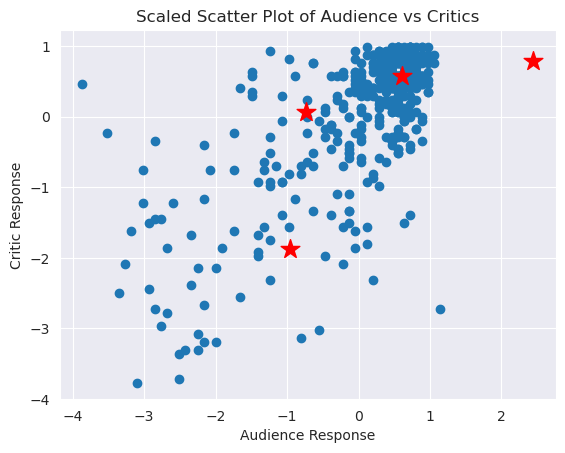

In [15]:
features = ['Audience Response', 'Critical Response']
df[features] = StandardScaler().fit_transform(df[features])
data = df[features].iloc[: , [0,1]].values
scaled_data = StandardScaler().fit_transform(data)
print(df[features])
##print(data)
##properly scaled
#sns.scatterplot(x=data[:,0], y=data[:,1], hue=df['cluster'], palette='Accent', s=100, zorder = 0)
#centroids = kmeans.cluster_centers_

# Plot the data points
#plt.scatter(scaled_df[:, 0], scaled_df[:, 1], c=kmeans.labels_)
# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='r', s=200, zorder=15)
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], zorder = 10)
plt.title('Scaled Scatter Plot of Audience vs Critics')
plt.xlabel('Audience Response')
plt.ylabel('Critic Response')
plt.show()

[[ 0.51968093  0.1081542 ]
 [-0.85078054  0.52451018]
 [ 0.72598254 -2.0463111 ]
 [ 2.48471708  0.17933849]]


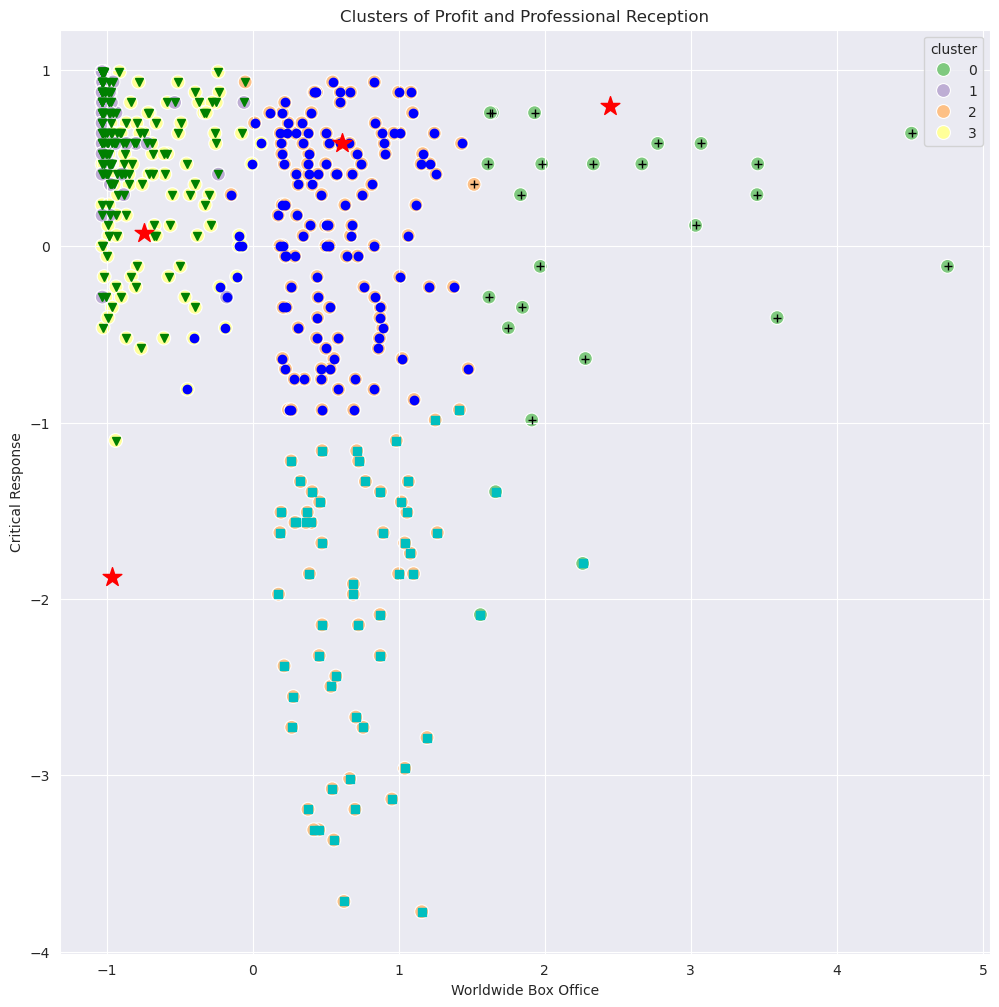

In [29]:
x1 = np.array(df['Worldwide Box Office'])
x2 = np.array(df['Critical Response'])

plt.figure(figsize=(12,12))
# create new plot and data
plt.plot()
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
colors = ['b', 'g', 'c', 'black']
markers = ['o', 'v', 's', '+']

# KMeans algorithm 
K = 4
kmeans_model = KMeans(n_clusters=K).fit(X)

print(kmeans_model.cluster_centers_)
centers = np.array(kmeans_model.cluster_centers_)

plt.plot()
plt.title('Clusters of Profit and Professional Reception')

for i, l in enumerate(kmeans_model.labels_):
    plt.plot(x1[i], x2[i], color=colors[l], marker=markers[l],ls='None', zorder = 5) ##overlaid on scatter plot

sns.scatterplot(x=df['Worldwide Box Office'], y=df['Critical Response'], hue=df['cluster'], palette='Accent', s=100, zorder = 0) 

plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='r', s=200, zorder=15)##always shows centroids
plt.show()

[[ 0.57136523  0.06512379]
 [ 0.62252679 -2.05680454]
 [-0.83715114  0.57135083]
 [ 2.51932545  0.16688233]]


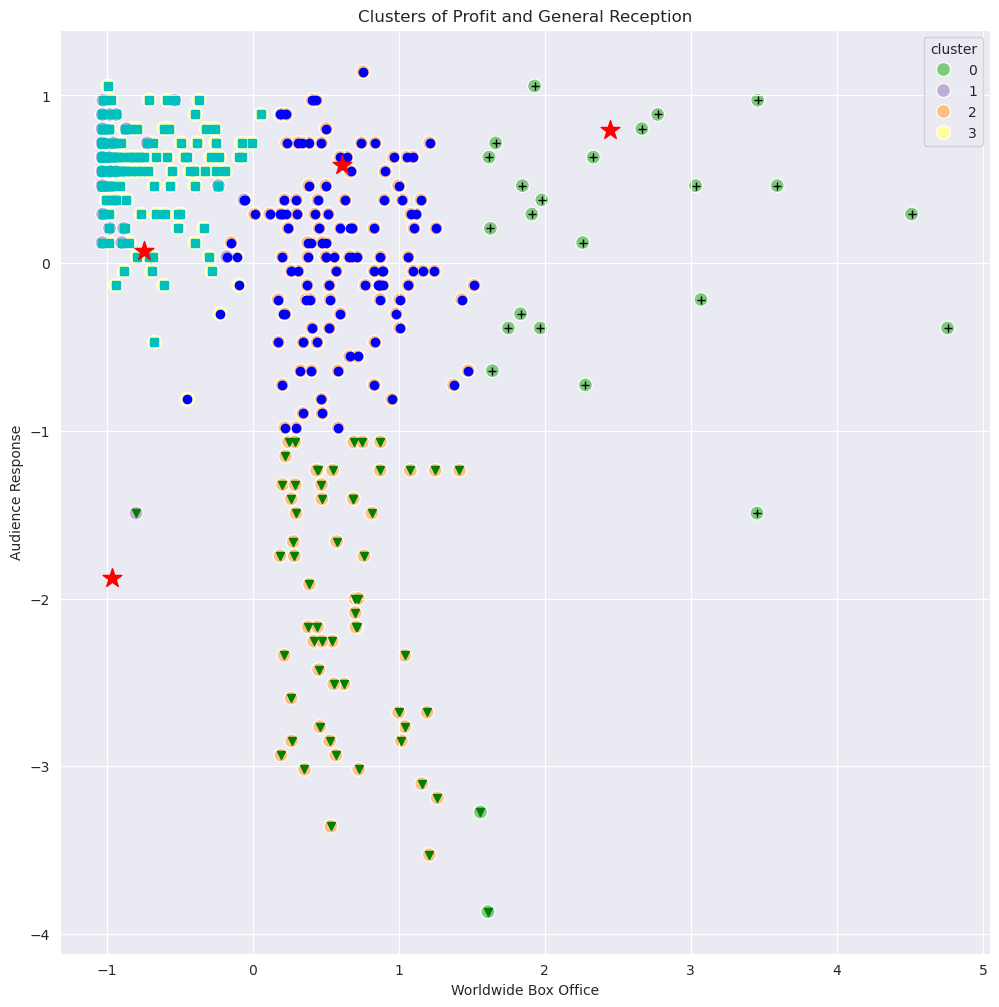

In [39]:
x1 = np.array(df['Worldwide Box Office'])
x2 = np.array(df['Audience Response'])

plt.figure(figsize=(12,12))
# create new plot and data
plt.plot()
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
colors = ['b', 'g', 'c', 'black']
markers = ['o', 'v', 's', '+']

# KMeans algorithm 
K = 4
kmeans_model = KMeans(n_clusters=K).fit(X)

print(kmeans_model.cluster_centers_)
centers = np.array(kmeans_model.cluster_centers_)

plt.plot()
plt.title('Clusters of Profit and General Reception')

for i, l in enumerate(kmeans_model.labels_):
    plt.plot(x1[i], x2[i], color=colors[l], marker=markers[l],ls='None', zorder = 5) ##overlaid on scatter plot

sns.scatterplot(x=df['Worldwide Box Office'], y=df['Audience Response'], hue=df['cluster'], palette='Accent', s=100, zorder = 0) 

plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='r', s=200, zorder=15)##always shows centroids
plt.show()

[[ 0.48325079  0.49842014]
 [-2.66044919 -1.04625197]
 [-0.50635587 -0.76537833]
 [-2.14784118 -2.76911678]]


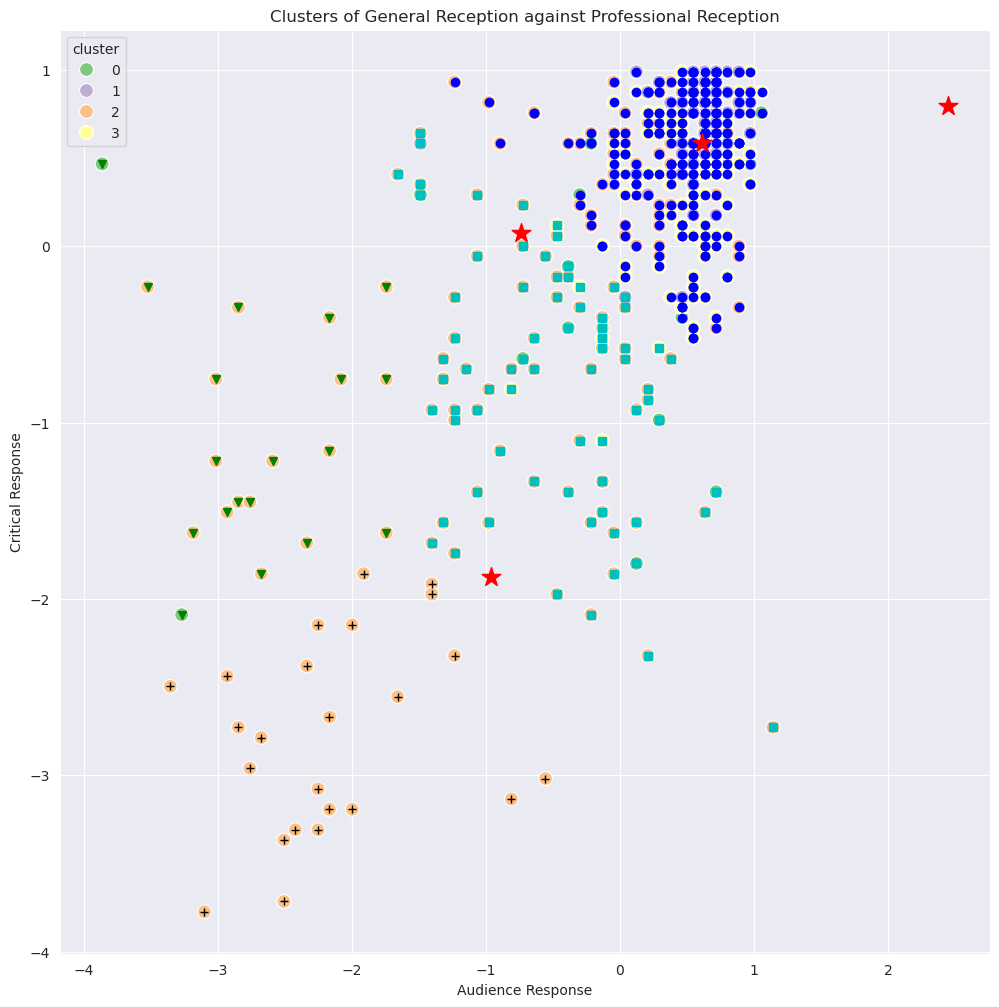

In [38]:
x1 = np.array(df['Audience Response'])
x2 = np.array(df['Critical Response'])
plt.figure(figsize=(12,12))
# create new plot and data
plt.plot()
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
colors = ['b', 'g', 'c', 'black']
markers = ['o', 'v', 's', '+']

# KMeans algorithm 
K = 4
kmeans_model = KMeans(n_clusters=K).fit(X)

print(kmeans_model.cluster_centers_)
centers = np.array(kmeans_model.cluster_centers_)

plt.plot()
plt.title('Clusters of General Reception against Professional Reception')

for i, l in enumerate(kmeans_model.labels_):
    plt.plot(x1[i], x2[i], color=colors[l], marker=markers[l],ls='None', zorder=15)

sns.scatterplot(x=df['Audience Response'], y=df['Critical Response'], hue=df['cluster'], palette='Accent', s=100, zorder=10) 

plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='r', s=200, zorder=20)##always shows centroids
plt.show()

[Text(0.5555555555555556, 0.9166666666666666, 'Worldwide Box Office <= 0.087\ngini = 0.668\nsamples = 414\nvalue = [25, 72, 180, 137]'),
 Text(0.3333333333333333, 0.75, 'Year of Release <= 1977.0\ngini = 0.467\nsamples = 212\nvalue = [0, 72, 3, 137]'),
 Text(0.4444444444444444, 0.8333333333333333, 'True  '),
 Text(0.2222222222222222, 0.5833333333333334, 'gini = 0.0\nsamples = 72\nvalue = [0, 72, 0, 0]'),
 Text(0.4444444444444444, 0.5833333333333334, 'Worldwide Box Office <= -0.064\ngini = 0.042\nsamples = 140\nvalue = [0, 0, 3, 137]'),
 Text(0.2222222222222222, 0.4166666666666667, 'Worldwide Box Office <= -0.168\ngini = 0.015\nsamples = 136\nvalue = [0, 0, 1, 135]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 130\nvalue = [0, 0, 0, 130]'),
 Text(0.3333333333333333, 0.25, 'Year of Release <= 2009.5\ngini = 0.278\nsamples = 6\nvalue = [0, 0, 1, 5]'),
 Text(0.2222222222222222, 0.08333333333333333, 'gini = 0.0\nsamples = 5\nvalue = [0, 0, 0, 5]'),
 Text(0.4444444444444444, 0.08

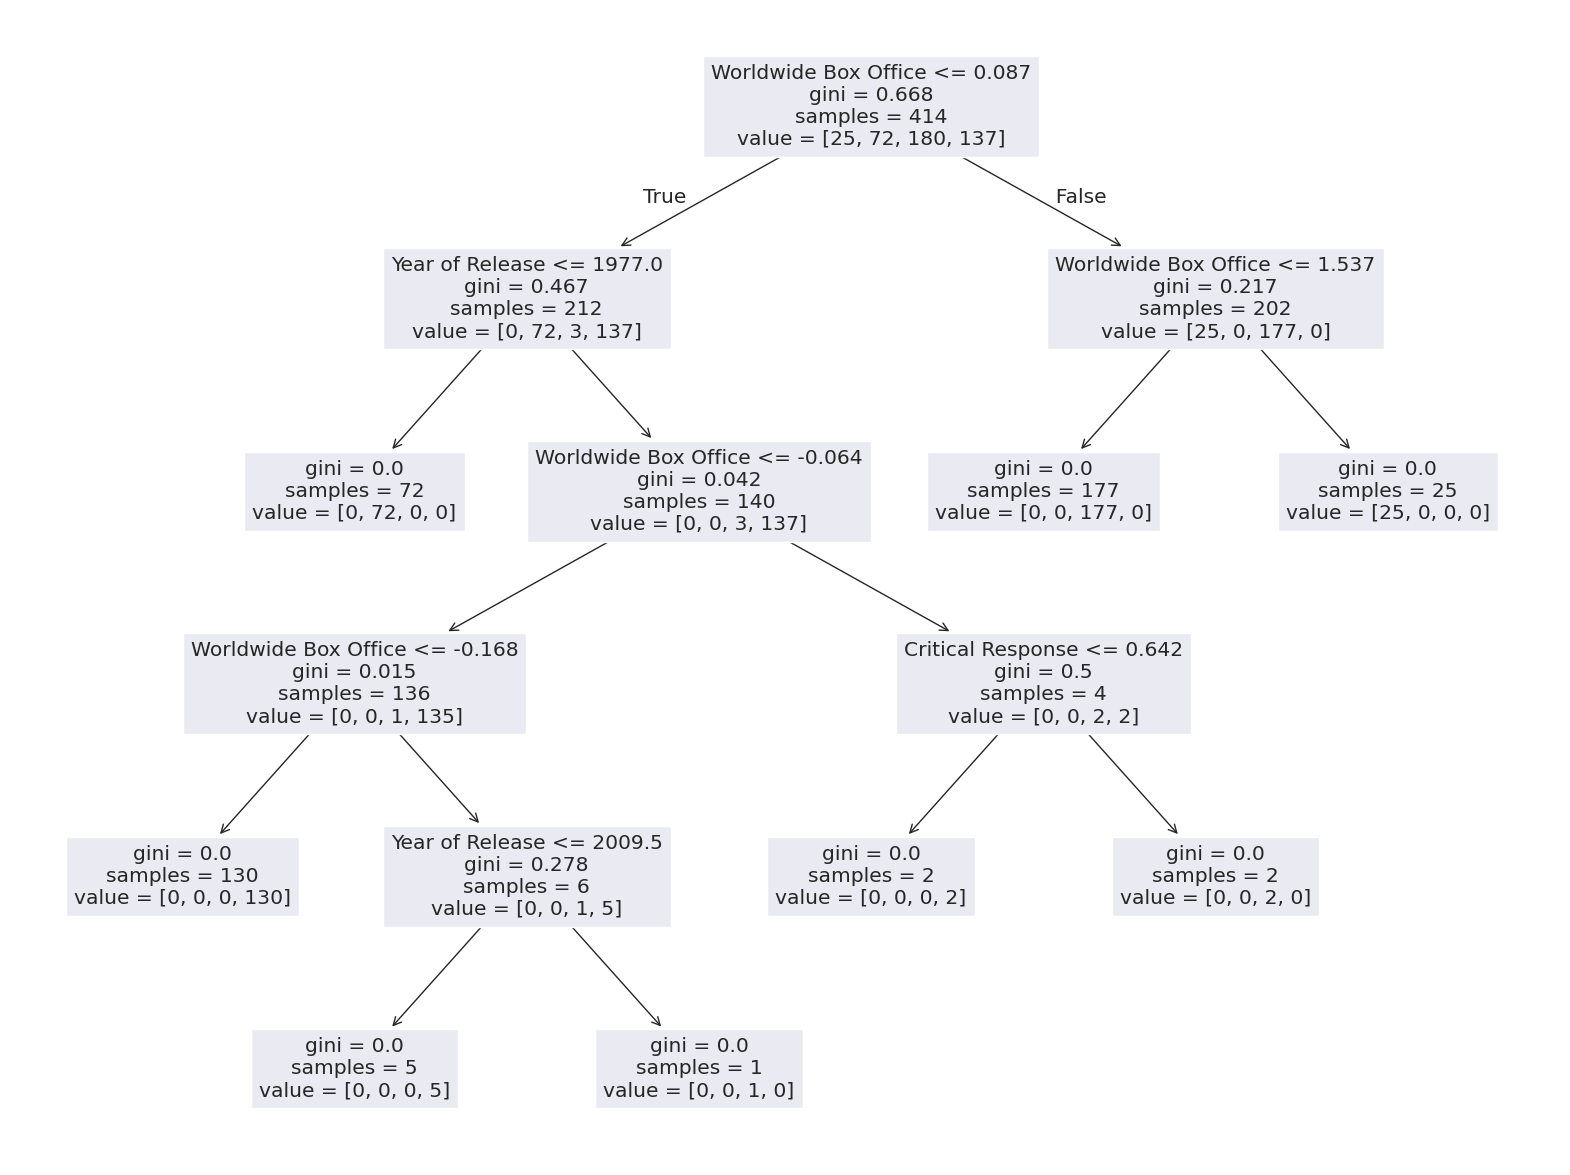

In [36]:
### Decision Trees ###
import pandas
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

features = ['Worldwide Box Office','Critical Response', 'Audience Response', 'Year of Release']
x = df[features]
y = df['cluster']

#print(df)
#print(x)
#print(y)
##^Testing

dtree = DecisionTreeClassifier()
dtree = dtree.fit(x, y)
plt.figure(figsize=(20,15))
tree.plot_tree(dtree, feature_names=features) 


In [23]:
### Interpretation ###

There are four kinds of movies that are formed by the opinions of professional and general audiences. 
The first category are Minivan Movies, as represented by Cluster 0. Audiences like them, critics dont, but it will still make lots of money
The second category are Classics, as represented by Cluster 1. Audiences and critics love them, but nobody is going to release them against so the profits are frozen. 
The second category are Blockbusters, as represented by Cluster 2. The make money first and foremost, and also end up being loved by everyone
The last category are Genre Movies, as represented by Cluster 3. They are defined by above-average response and average profits, as they are made to be enjoying experiences for a specific audience.

<class 'SyntaxError'>: invalid syntax (3400952560.py, line 3)